# XGBoost Phishing URL Detection - Training Notebook
## Focus: Minimizing False Positive Rate (FPR)

This notebook trains an **XGBClassifier** to detect phishing URLs with a strong emphasis on minimizing False Positives (classifying legitimate sites as phishing).

### Key Features:
- **XGBoost** with `tree_method='hist'` for fast training
- **Early Stopping** to prevent overfitting
- **Custom Threshold Optimization** to minimize FPR below 0.1%
- **Enhanced Evaluation**: FPR, Precision-Recall Curve, ROC Curve with optimal threshold
- **Feature Importance** via `xgboost.plot_importance`

In [25]:
import os
import sys
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# --- Dynamically find project root ---
current_dir = os.getcwd()
project_root = current_dir
while not os.path.exists(os.path.join(project_root, 'data')):
    project_root = os.path.dirname(project_root)
    if len(project_root) < 3:
        raise Exception("Could not find project root.")

INPUT_FILE = os.path.join(project_root, 'data', 'datasets', 'url_features_dataset.csv')
FEATURE_SCRIPT = os.path.join(project_root, 'src', 'features', 'extract_url_features.py')
MODEL_PATH = os.path.join(project_root, 'src', 'models', 'saved_models', 'url_xgboost.pkl')

# Ensure save directory exists
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

print(f"Project Root: {project_root}")
print(f"Input File:   {INPUT_FILE}")
print(f"Model Path:   {MODEL_PATH}")

Project Root: d:\project-3
Input File:   d:\project-3\data\datasets\url_features_dataset.csv
Model Path:   d:\project-3\src\models\saved_models\url_xgboost.pkl


In [26]:
# --- Load feature extraction module ---
if not os.path.exists(FEATURE_SCRIPT):
    print(f"ERROR: Feature script not found at {FEATURE_SCRIPT}")
else:
    spec = importlib.util.spec_from_file_location("extract_module", FEATURE_SCRIPT)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    extract_features = module.extract_features
    print("Success: 'extract_features' function loaded.")

Success: 'extract_features' function loaded.


In [27]:
# --- Complex SAFE URLs the model often misclassifies ---
# These legitimate URLs have complex structures (subdomains, long paths, query params)
hard_safe_urls = [
    # Google Services
    "https://gemini.google.com/app",
    "https://docs.google.com/document/d/1abc123xyz/edit?usp=sharing",
    "https://drive.google.com/file/d/1234567890/view",
    "https://mail.google.com/mail/u/0/#inbox",
    "https://accounts.google.com/signin/v2/identifier",
    "https://calendar.google.com/calendar/u/0/r",
    "https://meet.google.com/abc-defg-hij",
    "https://cloud.google.com/products/compute",
    "https://console.cloud.google.com/home/dashboard",
    "https://play.google.com/store/apps/details?id=com.example",
    "https://news.google.com/topstories?hl=en",
    "https://translate.google.com/?sl=en&tl=vi",
    "https://maps.google.com/maps?q=hanoi",
    "https://photos.google.com/album/abc123",
    "https://colab.research.google.com/drive/1xyz",
    # Microsoft Services
    "https://portal.azure.com/#create/Microsoft.VirtualMachine",
    "https://outlook.live.com/mail/0/inbox",
    "https://onedrive.live.com/?id=root",
    "https://login.microsoftonline.com/common/oauth2/authorize",
    "https://teams.microsoft.com/_#/conversations",
    "https://office.com/launch/word",
    "https://sharepoint.com/sites/company",
    "https://visualstudio.microsoft.com/downloads/",
    "https://learn.microsoft.com/en-us/docs",
    "https://dev.azure.com/organization/project",
    # Amazon Services
    "https://www.amazon.com/dp/B09G9FPHY6/ref=cm_sw_r",
    "https://aws.amazon.com/console/",
    "https://console.aws.amazon.com/ec2/v2/home",
    "https://s3.console.aws.amazon.com/s3/buckets",
    "https://signin.aws.amazon.com/signin",
    "https://prime.amazon.com/",
    "https://music.amazon.com/albums/B08XYZ",
    # Social Media & Entertainment
    "https://www.facebook.com/profile.php?id=100000",
    "https://m.facebook.com/login/?next=https%3A%2F%2Fm.facebook.com",
    "https://www.instagram.com/accounts/login/",
    "https://twitter.com/i/flow/login",
    "https://x.com/home",
    "https://www.linkedin.com/in/username/",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ&list=PLxyz",
    "https://studio.youtube.com/channel/UCxyz",
    "https://www.tiktok.com/@username/video/1234567890",
    "https://www.reddit.com/r/programming/comments/abc123",
    "https://discord.com/channels/123456789/987654321",
    "https://www.netflix.com/watch/80186799",
    "https://open.spotify.com/track/4iV5W9uYEdYUVa79Axb7Rh",
    # Developer & Tech
    "https://github.com/microsoft/vscode/blob/main/README.md",
    "https://stackoverflow.com/questions/12345678/how-to-fix",
    "https://gitlab.com/user/repo/-/merge_requests/1",
    "https://bitbucket.org/workspace/repo/src/main/",
    "https://npmjs.com/package/react",
    "https://pypi.org/project/tensorflow/",
    "https://hub.docker.com/_/python",
    "https://vercel.com/dashboard",
    "https://app.netlify.com/sites/mysite",
    "https://heroku.com/apps/myapp",
    "https://railway.app/project/abc123",
    # Finance & Business (legitimate)
    "https://www.paypal.com/myaccount/summary",
    "https://www.chase.com/personal/checking",
    "https://www.bankofamerica.com/online-banking/",
    "https://www.wellsfargo.com/biz/",
    "https://www.vanguard.com/us/LogonEmailAddress",
    "https://robinhood.com/account",
    # E-commerce & Services
    "https://www.ebay.com/itm/123456789012",
    "https://www.etsy.com/listing/1234567890",
    "https://www.alibaba.com/product-detail/xyz",
    "https://www.shopify.com/admin",
    "https://www.wordpress.com/post/mysite/123",
    "https://medium.com/@author/article-title-abc123",
    "https://www.notion.so/workspace/page-id",
    "https://trello.com/b/abc123/board-name",
    "https://slack.com/workspace/messages/channel",
    "https://zoom.us/j/1234567890?pwd=xyz",
    # Education & Reference
    "https://www.coursera.org/learn/machine-learning",
    "https://www.udemy.com/course/python-bootcamp/",
    "https://www.khanacademy.org/computing/computer-science",
    "https://en.wikipedia.org/wiki/Phishing",
    "https://scholar.google.com/citations?user=xyz",
    # Vietnamese sites
    "https://vnexpress.net/kinh-doanh",
    "https://shopee.vn/product/123456789",
    "https://tiki.vn/san-pham/abc-p12345",
    "https://lazada.vn/products/xyz-i123456.html",
    "https://momo.vn/payment",
    "https://vietcombank.com.vn/",
    "https://techcombank.com.vn/personal"
]

df_hard = pd.DataFrame({'url': hard_safe_urls, 'label': 0})
print(f"Added {len(hard_safe_urls)} complex safe URLs to training data")

Added 84 complex safe URLs to training data


In [28]:
# --- Load and merge datasets ---
df_original = pd.read_csv(INPUT_FILE)

print("Extracting features for hard samples...")
df_hard_features = extract_features(df_hard)

df_final = pd.concat([df_original, df_hard_features], ignore_index=True).fillna(0)
print(f"Total samples: {len(df_final)}")
print(f"  Phishing (1): {(df_final['label']==1).sum():,}")
print(f"  Benign   (0): {(df_final['label']==0).sum():,}")

Extracting features for hard samples...

  URL FEATURE EXTRACTION (Advanced)
  Processing 84 URLs...
[1/7] Parsing URLs...
[2/7] Extracting length features...
[3/7] Extracting count features...
[4/7] Extracting domain analysis features...
[5/7] Extracting keyword features...
[6/7] Extracting protocol & structure features...

  EXTRACTION COMPLETE
  69 features extracted for 84 URLs
  Time elapsed: 0.0s
Total samples: 26254
  Phishing (1): 15,000
  Benign   (0): 11,254


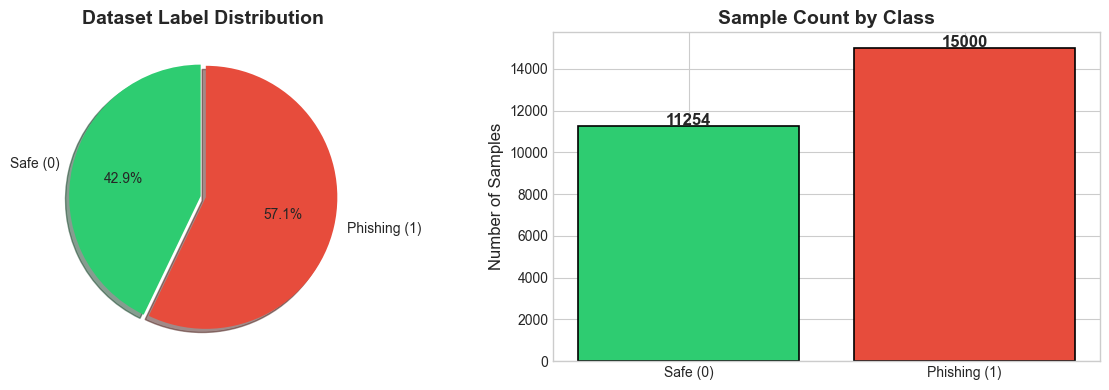

In [29]:
# --- Dataset Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# FIX: Thêm .sort_index() để luôn giữ (0) trước, (1) sau bất chấp số lượng
label_counts = df_final['label'].value_counts().sort_index()
labels_viz = ['Safe (0)', 'Phishing (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(label_counts, labels=labels_viz, autopct='%1.1f%%', colors=colors,
            explode=(0.02, 0.02), shadow=True, startangle=90)
axes[0].set_title('Dataset Label Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(labels_viz, label_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Sample Count by Class', fontsize=14, fontweight='bold')
for bar, count in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


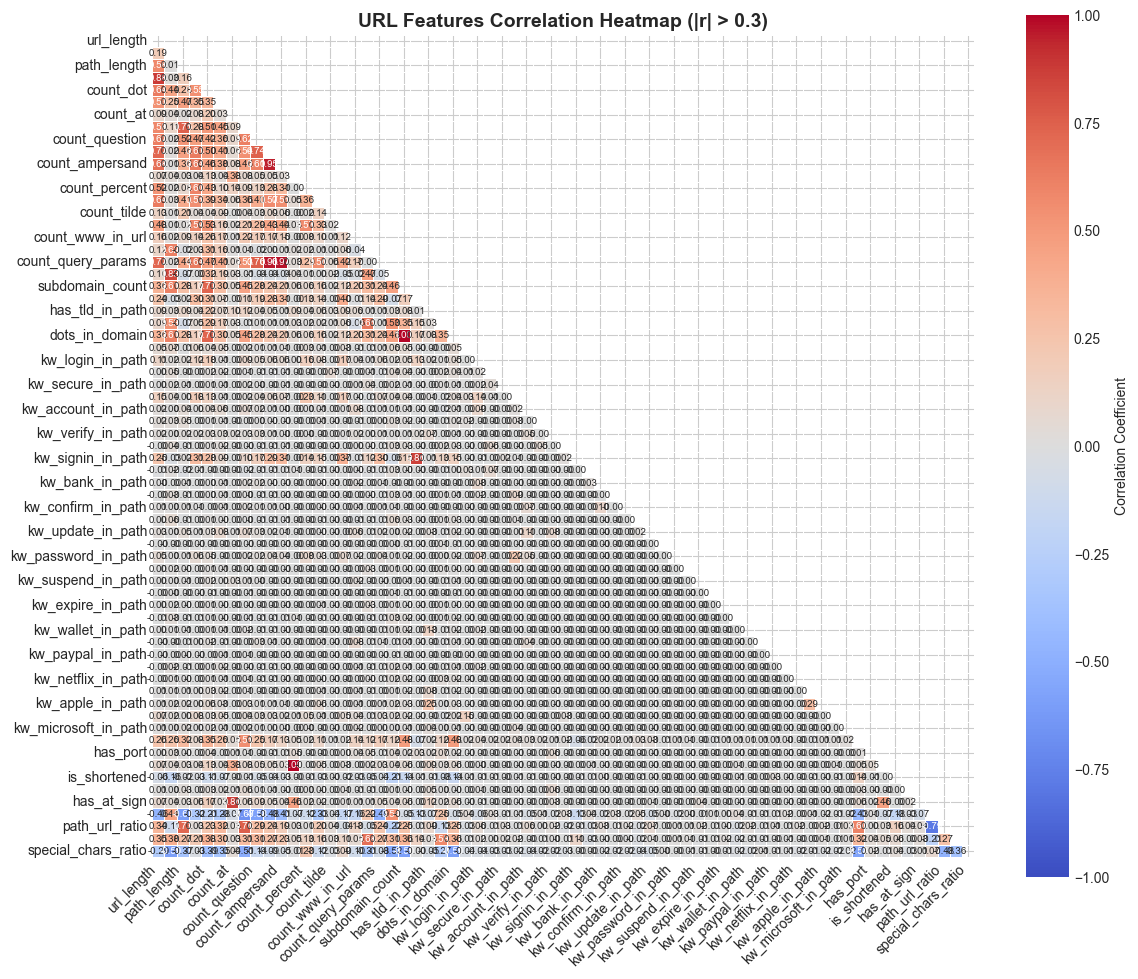


HIGH CORRELATIONS (|r| > 0.7):
  url_length <-> query_length: 0.880
  url_length <-> count_equal: 0.724
  url_length <-> count_query_params: 0.720
  hostname_length <-> domain_entropy: 0.835
  path_length <-> count_slash: 0.745
  path_length <-> path_url_ratio: 0.725
  count_dot <-> subdomain_count: 0.731
  count_dot <-> dots_in_domain: 0.731
  count_at <-> has_at_sign: 0.864
  count_slash <-> path_url_ratio: 0.757
  count_question <-> count_equal: 0.742
  count_question <-> count_query_params: 0.757
  count_equal <-> count_ampersand: 0.946
  count_equal <-> count_query_params: 0.962
  count_ampersand <-> count_query_params: 0.972
  count_hash <-> has_fragment: 1.000
  subdomain_count <-> dots_in_domain: 1.000
  is_ip_address <-> kw_signin_in_path: 0.859
  hostname_url_ratio <-> path_url_ratio: -0.790


In [30]:
# --- Correlation Heatmap (Top features only for readability) ---
feature_cols = df_final.drop(['url', 'label'], axis=1).columns
correlation_matrix = df_final[feature_cols].corr()

# Show only features with at least one |correlation| > 0.3 for readability
mask_important = (correlation_matrix.abs() > 0.3).any()
important_features = mask_important[mask_important].index.tolist()

if len(important_features) > 2:
    corr_subset = df_final[important_features].corr()
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_subset, dtype=bool))
    sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, annot_kws={'size': 7},
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('URL Features Correlation Heatmap (|r| > 0.3)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Print high correlations
print("\nHIGH CORRELATIONS (|r| > 0.7):")
print("=" * 50)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_val:.3f}")

## XGBoost Training with Early Stopping

The training pipeline:
1. Split data into **Train (64%)**, **Validation (16%)**, **Test (20%)**
2. Train XGBClassifier with `early_stopping_rounds=50` on the validation set
3. Find the **Optimal Threshold** that minimizes FPR below the target (< 0.1%)
4. Evaluate using the custom threshold instead of default 0.5

In [31]:
# --- Train / Validation / Test Split ---
X = df_final.drop(['url', 'label'], axis=1)
y = df_final['label']

# First split: 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: from the 80%, take 20% as validation -> 64% train, 16% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Train size:      {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation size: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test size:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Train size:      16,802 samples (64.0%)
Validation size: 4,201 samples (16.0%)
Test size:       5,251 samples (20.0%)


In [32]:
# --- XGBoost Training with Early Stopping ---
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    tree_method='hist',
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle imbalance
    use_label_encoder=False
)

# Train with early stopping on validation set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

best_iteration = xgb_model.best_iteration
print(f"\nTraining completed!")
print(f"Best iteration: {best_iteration}")
print(f"Best validation logloss: {xgb_model.best_score:.6f}")

[0]	validation_0-logloss:0.64998	validation_1-logloss:0.65034


d:\project-3\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [00:30:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-logloss:0.09927	validation_1-logloss:0.11717
[100]	validation_0-logloss:0.05960	validation_1-logloss:0.08705
[150]	validation_0-logloss:0.04744	validation_1-logloss:0.08069
[200]	validation_0-logloss:0.04188	validation_1-logloss:0.07766
[250]	validation_0-logloss:0.03691	validation_1-logloss:0.07518
[300]	validation_0-logloss:0.03327	validation_1-logloss:0.07373
[350]	validation_0-logloss:0.03005	validation_1-logloss:0.07219
[400]	validation_0-logloss:0.02753	validation_1-logloss:0.07150
[450]	validation_0-logloss:0.02540	validation_1-logloss:0.07116
[483]	validation_0-logloss:0.02470	validation_1-logloss:0.07119

Training completed!
Best iteration: 433
Best validation logloss: 0.070964


## FPR Optimization: Finding the Optimal Threshold

Instead of using the default `model.predict()` (threshold = 0.5), we use `predict_proba()` and search for the **highest threshold** that keeps:
- **FPR < 0.1%** (at most 1 in 1000 legitimate sites flagged as phishing)
- While maximizing **Recall** (catching as many phishing sites as possible)

**Formula:** `FPR = FP / (FP + TN)`

In [33]:
# --- Find Optimal Threshold for FPR < target ---

def find_optimal_threshold(y_true, y_proba, target_fpr=0.001):
    """
    Find the optimal classification threshold that keeps FPR below target_fpr.
    
    Args:
        y_true: True labels
        y_proba: Predicted probabilities for the positive class
        target_fpr: Maximum acceptable FPR (default: 0.1% = 0.001)
    
    Returns:
        optimal_threshold, achieved_fpr, achieved_tpr
    """
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true, y_proba)
    
    # Find all thresholds where FPR <= target
    valid_mask = fpr_vals <= target_fpr
    
    if not valid_mask.any():
        # If no threshold achieves target FPR, use the one with lowest FPR
        best_idx = np.argmin(fpr_vals[1:]) + 1  # skip first (0,0) point
        print(f"  [WARNING] Cannot achieve FPR < {target_fpr*100:.2f}%")
        print(f"  Using lowest available FPR: {fpr_vals[best_idx]*100:.4f}%")
    else:
        # Among valid thresholds, pick the one with highest TPR (recall)
        valid_tpr = tpr_vals.copy()
        valid_tpr[~valid_mask] = -1
        best_idx = np.argmax(valid_tpr)
    
    optimal_threshold = thresholds[min(best_idx, len(thresholds)-1)]
    return optimal_threshold, fpr_vals[best_idx], tpr_vals[best_idx]

# Get probabilities on TEST set
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold
TARGET_FPR = 0.01  # 1%
optimal_threshold, achieved_fpr, achieved_tpr = find_optimal_threshold(
    y_test, y_test_proba, target_fpr=TARGET_FPR
)

print(f"\n{'='*60}")
print(f"  FPR OPTIMIZATION RESULTS")
print(f"{'='*60}")
print(f"  Target FPR:        < {TARGET_FPR*100:.2f}%")
print(f"  Optimal Threshold: {optimal_threshold:.4f}")
print(f"  Achieved FPR:      {achieved_fpr*100:.4f}%")
print(f"  Achieved TPR:      {achieved_tpr*100:.2f}% (Recall)")
print(f"  Default Threshold: 0.5000")
print(f"{'='*60}")


  FPR OPTIMIZATION RESULTS
  Target FPR:        < 1.00%
  Optimal Threshold: 0.8933
  Achieved FPR:      0.9773%
  Achieved TPR:      94.53% (Recall)
  Default Threshold: 0.5000


In [34]:
# --- Apply Custom Threshold ---
y_pred_default = (y_test_proba >= 0.5).astype(int)
y_pred_optimized = (y_test_proba >= optimal_threshold).astype(int)

# Calculate FPR explicitly: FPR = FP / (FP + TN)
def calculate_fpr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return fpr, tn, fp, fn, tp

fpr_default, tn_d, fp_d, fn_d, tp_d = calculate_fpr(y_test, y_pred_default)
fpr_optimized, tn_o, fp_o, fn_o, tp_o = calculate_fpr(y_test, y_pred_optimized)

print(f"{'='*60}")
print(f"  COMPARISON: Default vs Optimized Threshold")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Default (0.5)':<18} {'Optimized ({:.4f})':<18}".format(optimal_threshold))
print(f"{'-'*60}")
print(f"{'FPR':<25} {fpr_default*100:<18.4f} {fpr_optimized*100:<18.4f}")
print(f"{'True Positives (TP)':<25} {tp_d:<18} {tp_o:<18}")
print(f"{'False Positives (FP)':<25} {fp_d:<18} {fp_o:<18}")
print(f"{'True Negatives (TN)':<25} {tn_d:<18} {tn_o:<18}")
print(f"{'False Negatives (FN)':<25} {fn_d:<18} {fn_o:<18}")
print(f"{'Accuracy':<25} {accuracy_score(y_test, y_pred_default)*100:<18.2f} {accuracy_score(y_test, y_pred_optimized)*100:<18.2f}")
print(f"{'='*60}")

print(f"\n  >>> FPR reduced from {fpr_default*100:.4f}% to {fpr_optimized*100:.4f}%")
if fpr_optimized < TARGET_FPR:
    print(f"  >>> TARGET MET: FPR < {TARGET_FPR*100:.2f}%")
else:
    print(f"  >>> TARGET NOT MET: FPR = {fpr_optimized*100:.4f}% (target: < {TARGET_FPR*100:.2f}%)")

  COMPARISON: Default vs Optimized Threshold
Metric                    Default (0.5)      Optimized (0.8933)
------------------------------------------------------------
FPR                       3.0209             0.9773            
True Positives (TP)       2948               2836              
False Positives (FP)      68                 22                
True Negatives (TN)       2183               2229              
False Negatives (FN)      52                 164               
Accuracy                  97.71              96.46             

  >>> FPR reduced from 3.0209% to 0.9773%
  >>> TARGET MET: FPR < 1.00%


OVERFITTING CHECK (threshold=0.8933)
Train Accuracy:      97.99%
Validation Accuracy: 95.93%
Test Accuracy:       96.46%
Train-Test Gap:      1.53%


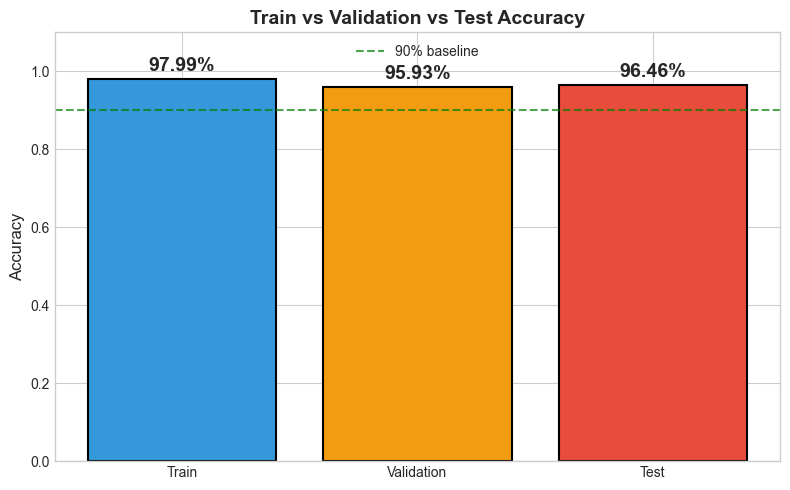


[OK] NO SIGNIFICANT OVERFITTING.


In [35]:
# --- Overfitting Check ---
train_acc = accuracy_score(y_train, (xgb_model.predict_proba(X_train)[:, 1] >= optimal_threshold).astype(int))
val_acc = accuracy_score(y_val, (xgb_model.predict_proba(X_val)[:, 1] >= optimal_threshold).astype(int))
test_acc = accuracy_score(y_test, y_pred_optimized)

print(f"{'='*50}")
print(f"OVERFITTING CHECK (threshold={optimal_threshold:.4f})")
print(f"{'='*50}")
print(f"Train Accuracy:      {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Test Accuracy:       {test_acc * 100:.2f}%")
print(f"Train-Test Gap:      {(train_acc - test_acc) * 100:.2f}%")
print(f"{'='*50}")

fig, ax = plt.subplots(figsize=(8, 5))
acc_labels = ['Train', 'Validation', 'Test']
acc_values = [train_acc, val_acc, test_acc]
bars = ax.bar(acc_labels, acc_values, color=['#3498db', '#f39c12', '#e74c3c'],
              edgecolor='black', linewidth=1.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Validation vs Test Accuracy', fontsize=14, fontweight='bold')
for bar, val in zip(bars, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2%}', ha='center', fontsize=14, fontweight='bold')
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.7, label='90% baseline')
ax.legend()
plt.tight_layout()
plt.show()

gap = train_acc - test_acc
if gap > 0.10:
    print("\n[WARNING] HIGH OVERFITTING DETECTED!")
elif gap > 0.05:
    print("\n[CAUTION] SLIGHT OVERFITTING detected.")
else:
    print("\n[OK] NO SIGNIFICANT OVERFITTING.")

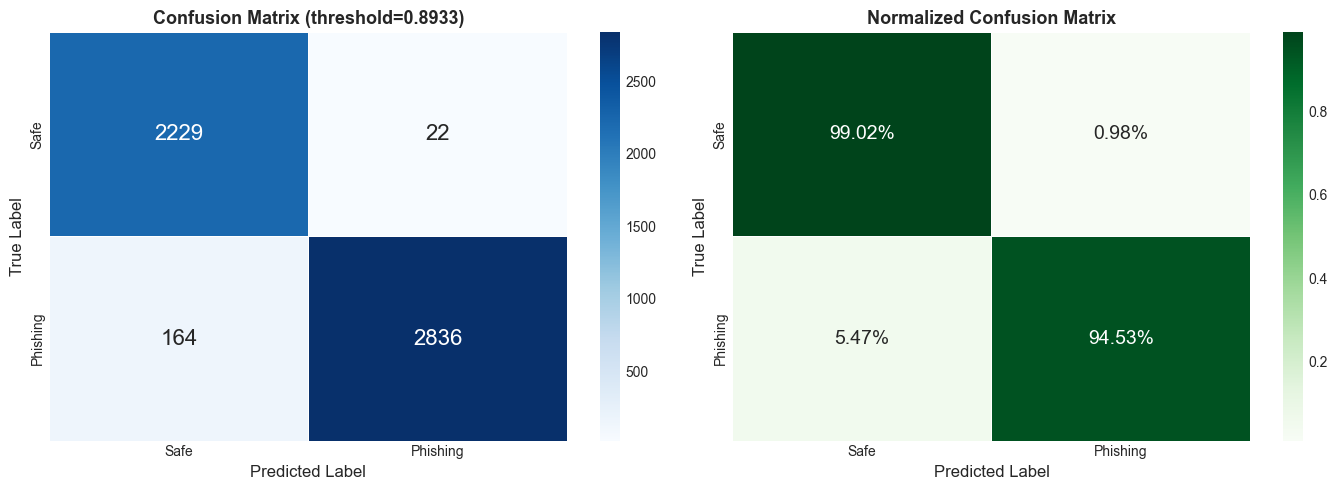


Explicit FPR = FP / (FP + TN) = 22 / (22 + 2229) = 0.9773%


In [36]:
# --- Confusion Matrix (Optimized Threshold) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
            annot_kws={'size': 16}, linewidths=0.5)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title(f'Confusion Matrix (threshold={optimal_threshold:.4f})', fontsize=13, fontweight='bold')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
            annot_kws={'size': 14}, linewidths=0.5)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Explicit FPR calculation
tn, fp, fn, tp = cm.ravel()
fpr_explicit = fp / (fp + tn)
print(f"\nExplicit FPR = FP / (FP + TN) = {fp} / ({fp} + {tn}) = {fpr_explicit*100:.4f}%")

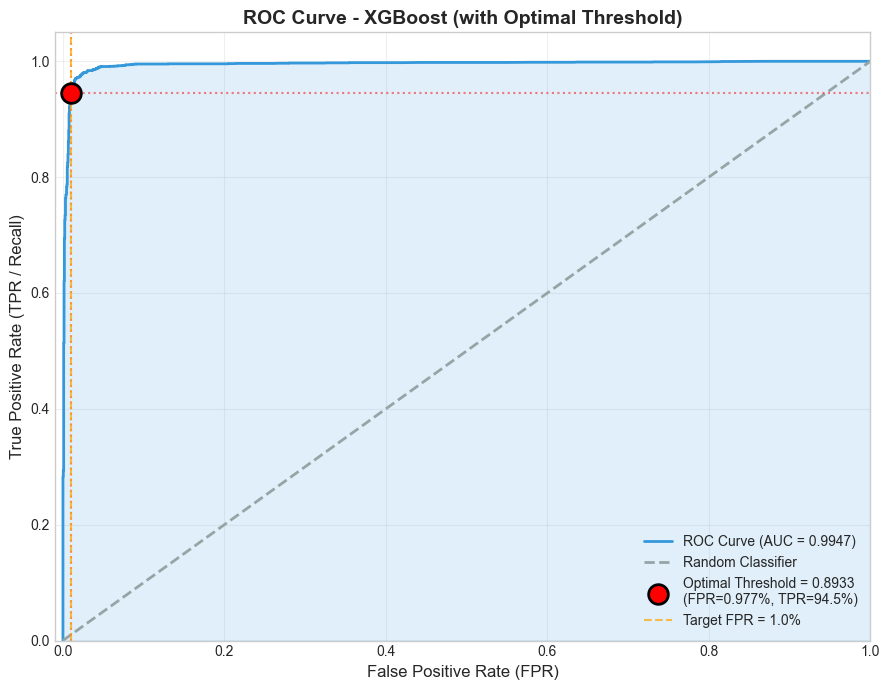

AUC Score: 0.9947


In [37]:
# --- ROC Curve with Optimal Threshold Highlighted ---
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(9, 7))
plt.plot(fpr_curve, tpr_curve, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Random Classifier')
plt.fill_between(fpr_curve, tpr_curve, alpha=0.15, color='#3498db')

# Highlight the optimal threshold point
plt.scatter([achieved_fpr], [achieved_tpr], color='red', s=200, zorder=5, edgecolors='black', linewidth=2,
            label=f'Optimal Threshold = {optimal_threshold:.4f}\n(FPR={achieved_fpr*100:.3f}%, TPR={achieved_tpr*100:.1f}%)')

# Draw lines to the point
plt.axvline(x=achieved_fpr, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=achieved_tpr, color='red', linestyle=':', alpha=0.5)

# Draw target FPR line
plt.axvline(x=TARGET_FPR, color='orange', linestyle='--', alpha=0.7, label=f'Target FPR = {TARGET_FPR*100:.1f}%')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('ROC Curve - XGBoost (with Optimal Threshold)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

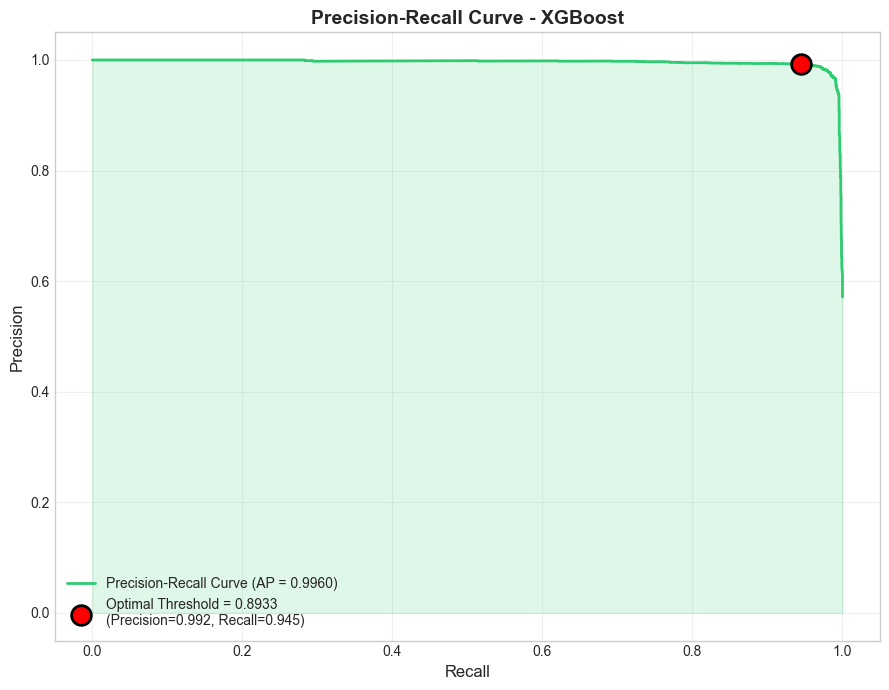

Average Precision Score: 0.9960


In [38]:
# --- Precision-Recall Curve ---
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(9, 7))
plt.plot(recall_curve, precision_curve, color='#2ecc71', lw=2,
         label=f'Precision-Recall Curve (AP = {avg_precision:.4f})')
plt.fill_between(recall_curve, precision_curve, alpha=0.15, color='#2ecc71')

# Find and plot the point for the optimal threshold
opt_precision = precision_score(y_test, y_pred_optimized, zero_division=0)
opt_recall = recall_score(y_test, y_pred_optimized)
plt.scatter([opt_recall], [opt_precision], color='red', s=200, zorder=5,
            edgecolors='black', linewidth=2,
            label=f'Optimal Threshold = {optimal_threshold:.4f}\n(Precision={opt_precision:.3f}, Recall={opt_recall:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")

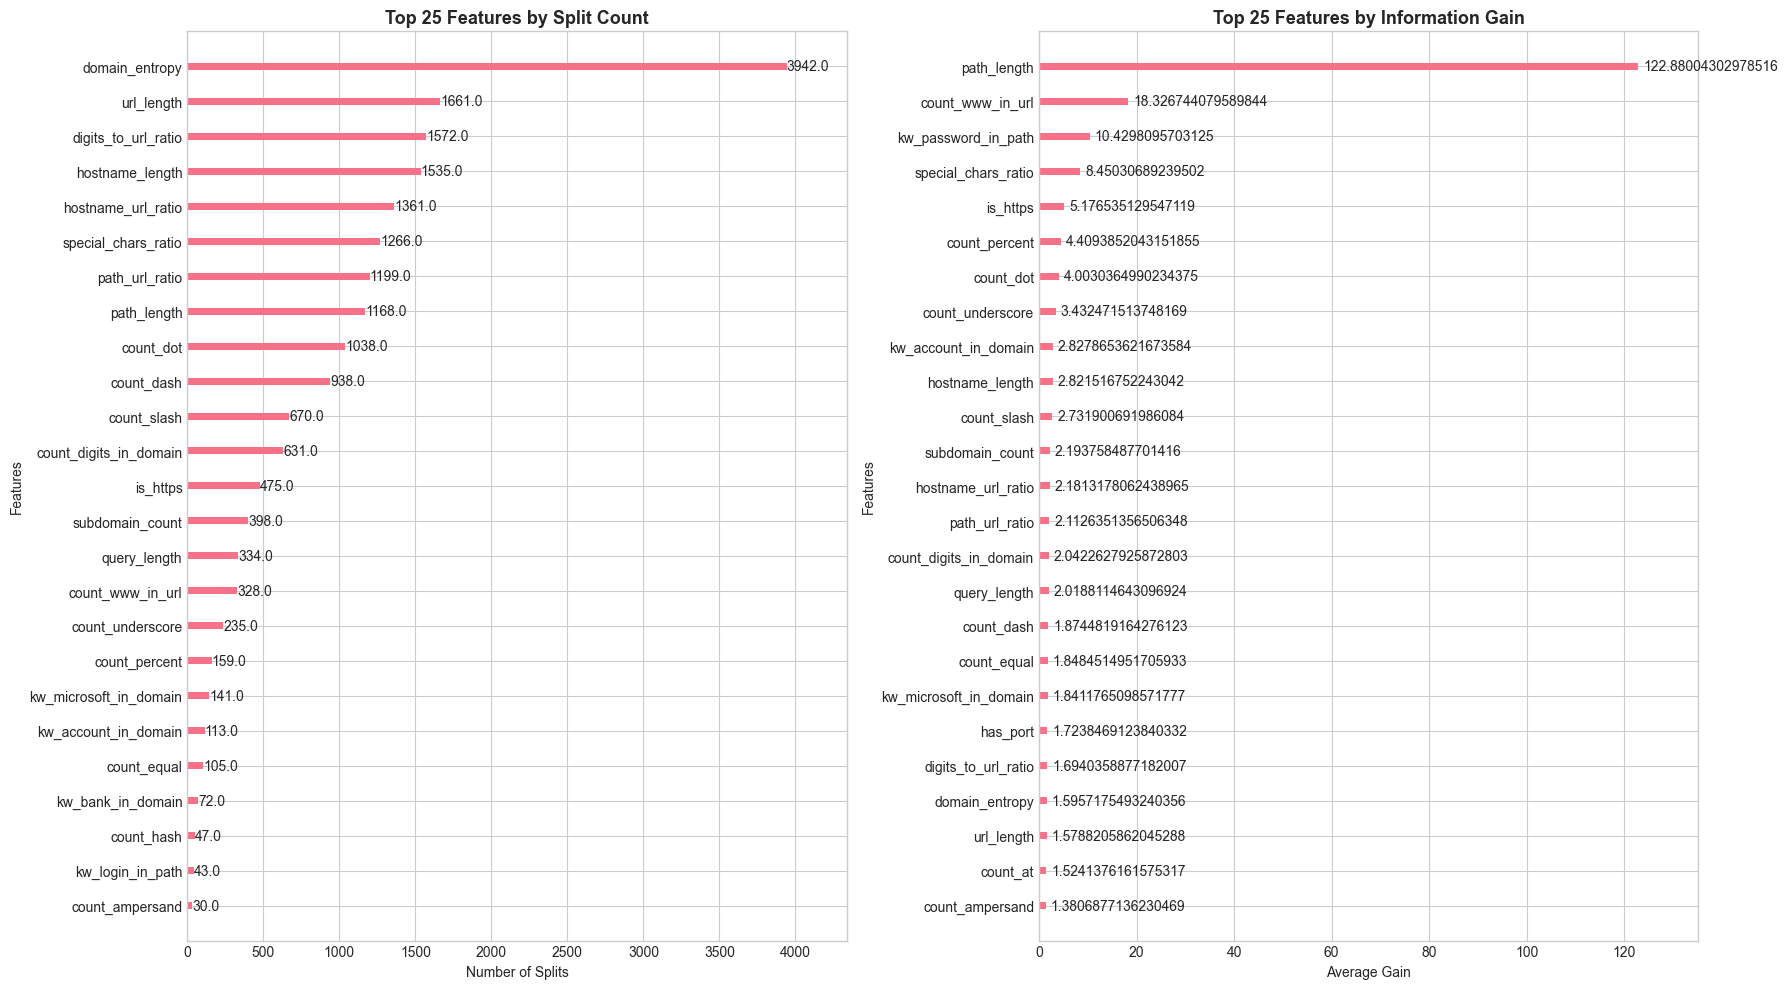


Top 10 Features by Gain:
  1. path_length: 122.8800
  2. count_www_in_url: 18.3267
  3. kw_password_in_path: 10.4298
  4. special_chars_ratio: 8.4503
  5. is_https: 5.1765
  6. count_percent: 4.4094
  7. count_dot: 4.0030
  8. count_underscore: 3.4325
  9. kw_account_in_domain: 2.8279
  10. hostname_length: 2.8215


In [39]:
# --- Feature Importance (XGBoost Native) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plot 1: Weight (number of times feature used in splits)
plot_importance(xgb_model, ax=axes[0], importance_type='weight', max_num_features=25,
                title='Feature Importance (Weight)', xlabel='Number of Splits')
axes[0].set_title('Top 25 Features by Split Count', fontsize=13, fontweight='bold')

# Plot 2: Gain (average improvement in loss)
plot_importance(xgb_model, ax=axes[1], importance_type='gain', max_num_features=25,
                title='Feature Importance (Gain)', xlabel='Average Gain')
axes[1].set_title('Top 25 Features by Information Gain', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 10 features by gain
print("\nTop 10 Features by Gain:")
booster = xgb_model.get_booster()
importance_gain = booster.get_score(importance_type='gain')
sorted_gain = sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)
for i, (feat, gain) in enumerate(sorted_gain[:10]):
    print(f"  {i+1}. {feat}: {gain:.4f}")

CLASSIFICATION REPORT (threshold=0.8933)
              precision    recall  f1-score   support

        Safe       0.93      0.99      0.96      2251
    Phishing       0.99      0.95      0.97      3000

    accuracy                           0.96      5251
   macro avg       0.96      0.97      0.96      5251
weighted avg       0.97      0.96      0.96      5251



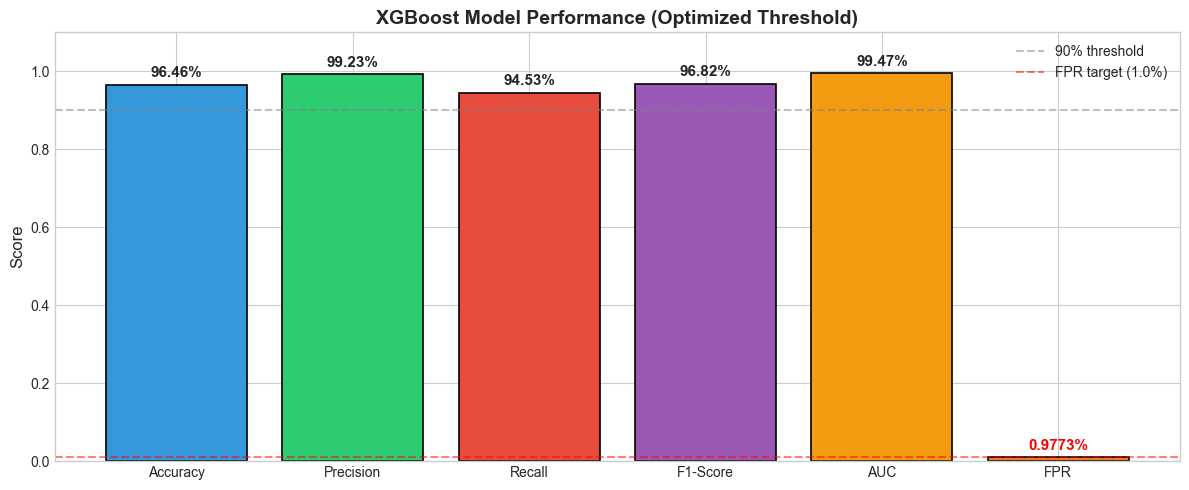

In [40]:
# --- Classification Report ---
print("=" * 60)
print(f"CLASSIFICATION REPORT (threshold={optimal_threshold:.4f})")
print("=" * 60)
print(classification_report(y_test, y_pred_optimized, target_names=['Safe', 'Phishing']))

# Metrics Summary
prec = precision_score(y_test, y_pred_optimized, zero_division=0)
rec = recall_score(y_test, y_pred_optimized)
f1 = f1_score(y_test, y_pred_optimized)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'FPR']
values = [test_acc, prec, rec, f1, roc_auc, fpr_optimized]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#e67e22']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('XGBoost Model Performance (Optimized Threshold)', fontsize=14, fontweight='bold')

for bar, val, name in zip(bars, values, metrics):
    if name == 'FPR':
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4%}', ha='center', fontsize=11, fontweight='bold', color='red')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2%}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
ax.axhline(y=TARGET_FPR, color='red', linestyle='--', alpha=0.5, label=f'FPR target ({TARGET_FPR*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
# --- Save XGBoost Model + Optimal Threshold ---
model_data = {
    'model': xgb_model,
    'optimal_threshold': optimal_threshold,
    'target_fpr': TARGET_FPR,
    'achieved_fpr': achieved_fpr,
    'feature_names': X.columns.tolist(),
    'best_iteration': best_iteration,
}

joblib.dump(model_data, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")
print(f"  - Includes optimal threshold: {optimal_threshold:.4f}")
print(f"  - Target FPR: < {TARGET_FPR*100:.2f}%")
print(f"  - Usage: data = joblib.load(path)")
print(f"           model = data['model']")
print(f"           threshold = data['optimal_threshold']")
print(f"           y_pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)")

Model saved to: d:\project-3\src\models\saved_models\url_xgboost.pkl
  - Includes optimal threshold: 0.8933
  - Target FPR: < 1.00%
  - Usage: data = joblib.load(path)
           model = data['model']
           threshold = data['optimal_threshold']
           y_pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
